## Parameters

- **resize** `(tuple -> (x, y))`  
  Resize input image to a specific size.

- **sample scale** `[array]`  
  Try different sample sizes to fit the input image.

- **crop switch coefficient** `(int, default=1.5)`  
  Precisely crop the switch from the input image.

- **filter parameters**:
  - `GAMMA = 2 * int(brightness / 10)`  
    reduces dark pixels aggressively.
  - `GAIN = 2`  
    Boosts bright pixels.
  - `CUTOFF = 0.15`  
    Absolute darkness cutoff.

- **segments' sizes** `[dict]`  
  Dictionary specifying the size of each segment.

- **tighten coefficient**  
  Crops segments like `"degrees"`, `"celcius"`, `"dot"`, `"auto"` more strictly from width to prevent overlap with other segments.

- **seven segments coordinates** `[array]`  
  Coordinates for each of the seven segments.

- **big lights**  
  - Policy 1: mean brightness threshold  
  - Policy 2: area threshold

- **little lights**  
  Mean brightness threshold.

- **degree lights**  
  Area threshold and box orientation (height / width).

- **seven segments area threshold**  
  Minimum area requirement for seven-segment components.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Crop Main Image

In [2]:
def crop_image(img_path, sample_path):
    # rgb_large = cv2.cvtColor(img_path, cv2.COLOR_BGR2RGB)
    # img_large = cv2.cvtColor(img_path, cv2.COLOR_BGR2GRAY)
    img_large = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    rgb_large = cv2.imread(img_path)
    img_small = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
    rgb_large = cv2.resize(rgb_large, (960, 1280))
    img_large = cv2.resize(img_large, (960, 1280))
    if img_large is None or img_small is None:
        raise ValueError("Could not load images")

    scales = [0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4]  # adjust scales if needed
    best_val = -1
    best_loc = None
    best_scale = 1.0
    best_template = img_small.copy()

    for s in scales:
        # Resize template
        temp_scaled = cv2.resize(img_small, (0, 0), fx=s, fy=s)
        res = cv2.matchTemplate(img_large, temp_scaled, cv2.TM_CCOEFF_NORMED)
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
        
        if max_val > best_val:
            best_val = max_val
            best_loc = max_loc
            best_scale = s
            best_template = temp_scaled.copy()
    print("sapmle best scale: ", best_scale)
    # print(f"Best match position: {best_loc}, Best scale: {best_scale}, Score: {best_val}")

    x, y = best_loc
    h, w = best_template.shape

    x_end = min(x + w, img_large.shape[1])
    y_end = min(y + h, img_large.shape[0])

    center_x = (x_end + x) / 2
    center_y = (y_end + y) / 2
    mask_x = (x_end - x)
    mask_y = (y_end - y)
    # print(center_x, ",", center_y)
    cropped = rgb_large[int(center_y - 1.5 * mask_y): int(center_y + 1.5 * mask_y), int(center_x - 1.5 * mask_x): int(center_x + 1.5 * mask_x)]

    cv2.imshow("Cropped Image", cropped)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    return cropped



# Filter image

In [3]:
def filter(rgb_img):
    # rgb_img = cv2.imread(rgb_img)
    brightness = np.mean(rgb_img)
    print("Brightness = ", brightness)
    bw = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2GRAY)
    bw = bw.astype(np.float32) / 255.0

    GAMMA  = 2 * int(brightness/10)  # >1 kills dark pixels hard
    GAIN   =  2  # boosts bright pixels
    CUTOFF = 0.15  # absolute darkness cutoff

    result = np.power(bw, GAMMA)
    result[result < CUTOFF] = 0.0
    result *= GAIN
    result = np.clip(result, 0, 1)

    bw = np.zeros((600, 800, 3), dtype=np.uint8)
    output = (result * 255).astype(np.uint8) 

    # cv2.imshow("Bold Light / Dark OFF", output)
    # # cv2.imwrite("bold_light_dark_off.png", output)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()
    
    return output

# for i in range(10):
#     filter(f"samples/photo_{i+1}_2025-12-30_19-29-44.jpg")


# Segment

In [4]:
# coordinates
# (row, col, width, height) 

coordinates = {
        "left_up"  : (0, 0, 2, 3),
        "right_up" :(0, 4, 2, 3),
        "degrees" : (3, 1, 1, 3),
        "left_7seg" : (3, 2, 1, 3),
        "right_7seg" : (3, 3, 1, 3),
        "celcius" : (3, 4, 1, 1),
        "dot" : (4, 4, 1, 1),
        "auto" : (5, 4, 1, 1),
        "left_down" : (6, 0, 2, 3),
        "middle_down" : (6, 2, 2, 3),
        "right_down" : (6, 4, 2, 3)
    }

tighten_coef = 0.1
def crop_segments(img):
    cell_w = int(img.shape[0] / 6)
    cell_h = int(img.shape[1] / 9)
    segments = dict()
    fig, axes = plt.subplots(3, 4, figsize=(10,5))
    axes = axes.flatten()
    for i, key in enumerate(coordinates):
        c = coordinates[key]
        segments[key] = img[c[0] * cell_h: (c[0] + c[3]) * cell_h, c[1] * cell_w: (c[1] + c[2])* cell_w]
        if key in ["degrees", "celcius", "dot", "auto"]:
            segments[key] = segments[key][:, int(tighten_coef * cell_w): int(-tighten_coef * cell_w)] # Tighten width for these sensitive segments.
        
        axes[i].imshow(segments[key], cmap='gray')
        axes[i].axis("off")
        axes[i].set_title(key)
    plt.tight_layout()
    plt.show()
        
    return segments

# segments = crop_segments(filter(cropped))

# Check Lights

In [5]:
SEVEN_SEGMENTS = {
    0: [1, 1, 1, 1, 1, 1, 0],
    1: [0, 1, 1, 0, 0, 0, 0],
    2: [1, 1, 0, 1, 1, 0, 1],
    3: [1, 1, 1, 1, 0, 0, 1],
    4: [0, 1, 1, 0, 0, 1, 1],
    5: [1, 0, 1, 1, 0, 1, 1],
    6: [1, 0, 1, 1, 1, 1, 1],
    7: [1, 1, 1, 0, 0, 0, 0],
    8: [1, 1, 1, 1, 1, 1, 1],
    9: [1, 1, 1, 1, 0, 1, 1],
}



def big_light_check(img, key):
    # TODO
    mean_brightness = np.sum(img) / (img.shape[0] * img.shape[1])
    print(key, " mean brightness: ", mean_brightness)
    threshold = 1  # good starting point — adjust if needed
    status = "ON" if mean_brightness > threshold else "OFF"
        
    return status
    
def little_light_check(img, key):
    mean_brightness = np.sum(img) / (img.shape[0] * img.shape[1])
    print(key, " mean brightness: ", mean_brightness)
    threshold = 5 # good starting point — adjust if needed
    status = "ON" if mean_brightness > threshold else "OFF"
    
    return status


def degree_light_check(img):
    gray = img.copy()
    
    # Convert to color for drawing
    output = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    
    # Binarize
    _, binary = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
    
    # Connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)
    
    num_lights = 0
    
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        # print("degree h/w: ", h/w)
        if area > 50 and (h/w) < 0.6 :  # to make sure components are horizantal and their area are bigger than a treshold so they aren't noise(usually are above 90)
            num_lights += 1
            # Draw green rectangle
            # cv2.rectangle(output, (x, y), (x+w, y+h), (0, 255, 0), 2)
            # print("area: ", area)
    # cv2.imshow("Detected Lights", output)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()

    return num_lights

def seven_segment_light_check(img):
    gray = img.copy()
    
    # Convert to color for drawing
    output = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    
    # Binarize
    _, binary = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
    
    # Connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)
    
    on_segs = np.zeros(7, dtype=int)
    min_area = 100
    min_sum  = 3000
    
    valid_centers = []
    
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        
        if area > min_area:
            blob_sum = np.sum(gray[y:y+h, x:x+w])
            if blob_sum > min_sum:
                cx = centroids[i][0]
                cy = centroids[i][1]
                valid_centers.append((cx, cy))
                # Draw green rectangle
    #             cv2.rectangle(output, (x, y), (x+w, y+h), (0, 255, 0), 2)
    
    # cv2.imshow("Detected Lights", output)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()

    if not valid_centers:
        return "OFF"
    
        # Get image center and normalize positions
    h, w = gray.shape
    
    
    # Classify each valid center to a segment
    for cx, cy in valid_centers:
        if cy < h * 0.25:                  # top part of digit
            on_segs[0] = 1                 # A
        elif cy > h * 0.75:                # bottom part
            on_segs[3] = 1                 # D
        elif h * 0.4 < cy < h * 0.6:       # middle horizontal zone
            on_segs[6] = 1                 # G
        elif cx > w * 0.55:                # right half
            if cy < h * 0.5:
                on_segs[1] = 1             # B (upper right)
            else:
                on_segs[2] = 1             # C (lower right)
        else:                              # left half
            if cy < h * 0.5:
                on_segs[5] = 1             # F (upper left)
            else:
                on_segs[4] = 1             # E (lower left)
    
    for k in SEVEN_SEGMENTS:
        if np.sum(np.abs(on_segs - np.array(SEVEN_SEGMENTS[k]))) == 0:
            return k
    
    print("❌Error on Seven Segments' LED")
    return on_segs
    

def check_lights(segments):
    results = {}
    for key in segments:
        if key in [ "left_up" , "right_up" , "left_down" , "middle_down" , "right_down"]:
            results[key] = big_light_check1(segments[key], key)

        elif key in ["left_7seg", "right_7seg"]:    
            results[key]= seven_segment_light_check(segments[key])
            
        elif key in ["celcius" , "dot" , "auto"]:
            results[key] = little_light_check(segments[key], key)

        elif key == "degrees":
            results[key] = degree_light_check(segments[key])

    return results

# check_lights(segments)

In [6]:
def big_light_check1(img, key):
    gray = img.copy()
    
    # Convert to color for drawing
    output = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    
    # Binarize
    _, binary = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
    
    # Connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)
    
    min_area = 100
    min_sum  = 3000
    
    valid_centers = []
    
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        
        if area > min_area:
            blob_sum = np.sum(gray[y:y+h, x:x+w])
            if blob_sum > min_sum:
                cx = centroids[i][0]
                cy = centroids[i][1]
                valid_centers.append((cx, cy))
                # Draw green rectangle
                cv2.rectangle(output, (x, y), (x+w, y+h), (0, 255, 0), 2)
                print(f"{key} area: {area},, {w*h}")  
                print(f"{key} blob_sum: {blob_sum/(w*h)}")  
    cv2.imshow("Detected Lights", output)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    if not valid_centers:
        return "OFF"
    return "ON"


# TEST

sapmle best scale:  1.4
Brightness =  72.15149281934997


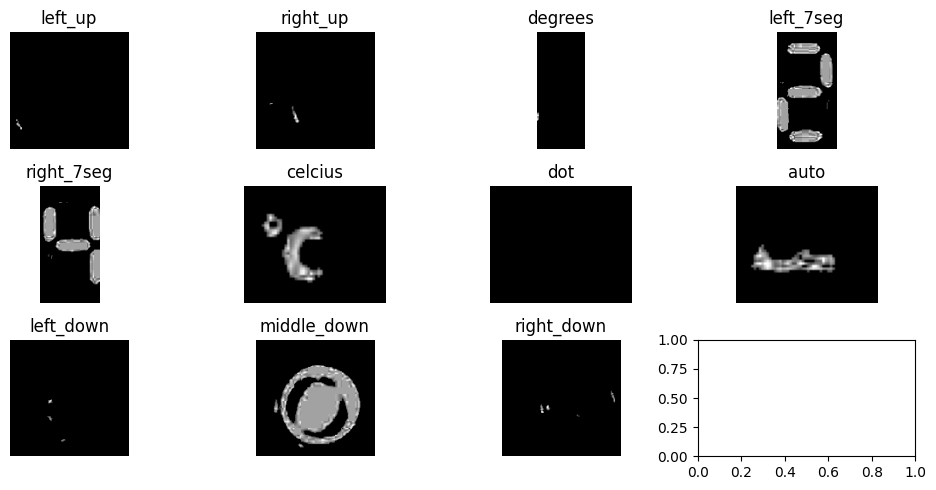

celcius  mean brightness:  13.38276397515528
dot  mean brightness:  0.0
auto  mean brightness:  10.583850931677018
middle_down area: 5388,, 9486
middle_down blob_sum: 88.92051444233607
{'left_up': 'OFF', 'right_up': 'OFF', 'degrees': 0, 'left_7seg': 2, 'right_7seg': 4, 'celcius': 'ON', 'dot': 'OFF', 'auto': 'ON', 'left_down': 'OFF', 'middle_down': 'ON', 'right_down': 'OFF'}


In [ ]:
# trg = r"C:\Users\Ata\Pictures\Camera Roll\WIN_20260219_16_42_06_Pro.jpg"
# trg = r"D:\.University\7\Project Parlar\samples\photo_8_2025-12-30_19-29-44.jpg"
# trg = r"D:\.University\7\Project Parlar\20251225_122935.jpg"
trg = r"C:\Users\Ata\Pictures\Camera Roll\WIN_20260219_16_22_53_Pro.jpg"
cropped_img = crop_image(trg, "samp3.jpg")
filtered_img = filter(cropped_img)
segments = crop_segments(filtered_img)
result = check_lights(segments)
print(result)

sapmle best scale:  1.1
Brightness =  78.5467217630854


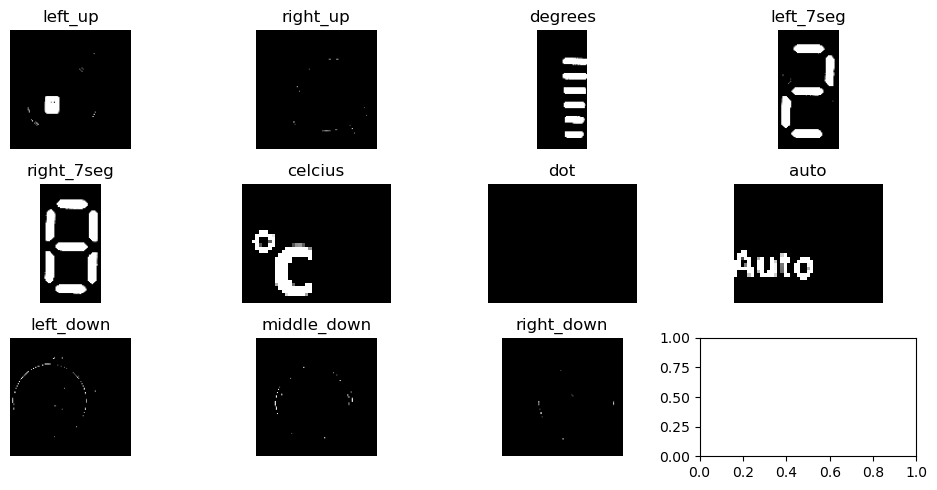

left_up area: 213,, 224
left_up blob_sum: 233.26339285714286
celcius  mean brightness:  19.45925925925926
dot  mean brightness:  0.0
auto  mean brightness:  14.20679012345679
{'left_up': 'ON', 'right_up': 'OFF', 'degrees': 6, 'left_7seg': 2, 'right_7seg': 8, 'celcius': 'ON', 'dot': 'OFF', 'auto': 'ON', 'left_down': 'OFF', 'middle_down': 'OFF', 'right_down': 'OFF'}


In [8]:
# trg = r"C:\Users\Ata\Pictures\Camera Roll\WIN_20260219_16_42_06_Pro.jpg"
# trg = r"D:\.University\7\Project Parlar\samples\photo_8_2025-12-30_19-29-44.jpg"
trg = r"D:\.University\7\Project Parlar\20251225_122935.jpg"
# trg = r"C:\Users\Ata\Pictures\Camera Roll\WIN_20260219_16_22_53_Pro.jpg"
cropped_img = crop_image(trg, "samp3.jpg")
filtered_img = filter(cropped_img)
cv2.imshow("Detected Lights", filtered_img)
cv2.waitKey(0)
cv2.destroyAllWindows()
segments = crop_segments(filtered_img)
result = check_lights(segments)
print(result)

In [ ]:
import time
cap = cv2.VideoCapture(0)

while True:
    time.sleep(5)
    ret, frame = cap.read()
    if not ret:
        break

    (h, w) = frame.shape[:2]
    cv2.imshow("Face Recognition", frame)
    
    trg = frame
    cropped_img = crop_image(trg, "samp3.jpg")
    filtered_img = filter(cropped_img)
    segments = crop_segments(filtered_img)
    result = check_lights(segments)
    print(result)
            # --> Run dlib face detection here
            
    if cv2.waitKey(1) == 27:  # ESC key to break
        break

cap.release()
cv2.destroyAllWindows()
    